# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the integrated dataset before feature engineering and predictive modeling. This analysis focuses on identifying the distribution of variables, temporal trends, relationships between air quality, fire activity, and meteorological conditions, and potential anomalies within the dataset. The insights obtained during this stage provide the foundation for subsequent feature engineering, hypothesis testing, and machine learning.

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

sns.set_theme(style="whitegrid", context="notebook")

master_df = pd.read_csv(r"C:\Users\ASUS\Documents\Delhi_Population_project1\Master_cleaned_dataset\master_dataset.csv")
master_df["Date"] = pd.to_datetime(master_df["Date"])

## Visualization Configuration

To ensure consistency and readability throughout the exploratory data analysis, a common visualization style is defined before generating any figures. A unified theme, font, color palette, and layout are applied across all visualizations to maintain a professional and consistent presentation.

In [9]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "font.family": "DejaVu Sans"
})

px.defaults.template = "plotly_white"
px.defaults.width = 900
px.defaults.height = 550

COLOR_PALETTE  = {
    "AQI": "#1f77b4",
    "PM2.5": "#4c78a8",
    "Fire": "#ff7f0e",
    "Wind": "#2ca02c",
    "Temperature": "#d62728",
    "Humidity": "#17becf"
}

## 1. Dataset Overview

The analysis begins by examining the overall structure of the integrated master dataset. This includes verifying the number of observations, variables, data types, missing values, and descriptive statistics to ensure that the dataset is complete and suitable for further analysis.

In [10]:
print("Shape:", master_df.shape)

display(master_df.head())

print("\nData Types")
display(master_df.dtypes)

print("\nMissing Values")
display(master_df.isnull().sum())

display(master_df.describe().T.round(2))

Shape: (1851, 15)


,Date,AQI,AQI_Bucket,PM2.5,Fire_Count,Total_FRP,Mean_FRP,Max_FRP,Mean_U10,Mean_V10,Mean_Wind_Speed,Max_Wind_Speed,Avg_Temperature_C,Avg_DewPoint_C,Relative_Humidity
0,2015-01-01,472.0,Severe,313.22,30,129.63,4.321000,11.74,-0.970402,-0.688204,1.757655,2.625952,15.814055,10.725815,71.76
1,2015-01-02,454.0,Severe,186.18,15,84.92,5.661333,16.66,-1.682431,-0.455764,1.946573,3.647534,15.319465,13.485620,88.82
2,2015-01-03,143.0,Moderate,87.18,4,5.93,1.482500,2.07,0.962810,-0.866344,1.492209,2.766795,15.595728,14.065458,90.61
3,2015-01-04,319.0,Very Poor,151.84,15,81.51,5.434000,15.46,1.773298,-1.831503,2.604788,3.700177,13.921083,11.270265,84.05
4,2015-01-05,325.0,Very Poor,146.60,34,110.50,3.250000,8.84,4.105233,-2.425379,4.797141,7.469673,14.195888,9.797250,74.85



Data Types


Date                 datetime64[ns]
AQI                         float64
AQI_Bucket                   object
PM2.5                       float64
Fire_Count                    int64
Total_FRP                   float64
Mean_FRP                    float64
Max_FRP                     float64
Mean_U10                    float64
Mean_V10                    float64
Mean_Wind_Speed             float64
Max_Wind_Speed              float64
Avg_Temperature_C           float64
Avg_DewPoint_C              float64
Relative_Humidity           float64
dtype: object


Missing Values


Date                 0
AQI                  0
AQI_Bucket           0
PM2.5                0
Fire_Count           0
Total_FRP            0
Mean_FRP             0
Max_FRP              0
Mean_U10             0
Mean_V10             0
Mean_Wind_Speed      0
Max_Wind_Speed       0
Avg_Temperature_C    0
Avg_DewPoint_C       0
Relative_Humidity    0
dtype: int64

,count,mean,min,25%,50%,75%,max,std
Date,1851,2017-10-01 17:56:41.620745472,2015-01-01 00:00:00,2016-05-06 12:00:00,2017-10-10 00:00:00,2019-02-17 12:00:00,2020-07-01 00:00:00,NaN
AQI,1851.0,267.704484,30.0,172.5,268.0,352.0,716.0,117.929309
PM2.5,1851.0,122.505132,11.81,61.54,101.02,161.17,685.36,83.353626
Fire_Count,1851.0,303.855754,1.0,11.0,40.0,133.0,8659.0,758.97854
Total_FRP,1851.0,1963.02107,0.44,37.06,157.77,672.63,61479.85,5348.478384
Mean_FRP,1851.0,4.360747,0.44,3.093439,4.03,5.485909,23.553592,2.151164
Max_FRP,1851.0,25.66698,0.44,6.845,13.58,33.15,211.37,29.940094
Mean_U10,1851.0,0.342097,-5.882892,-0.894279,0.514215,1.673209,5.482586,1.751806
Mean_V10,1851.0,-0.465155,-3.323114,-1.274002,-0.565384,0.271519,3.811652,1.056102
Mean_Wind_Speed,1851.0,2.357453,0.889525,1.781332,2.219227,2.759986,6.747771,0.767559


### Findings

The integrated master dataset consists of **1,851 daily observations** and **15 variables** representing air quality, fire activity, wind characteristics, and meteorological conditions. No missing values remain after preprocessing, indicating that the dataset is complete and ready for analysis. The descriptive statistics reveal substantial variability across AQI and fire-related variables, suggesting that the dataset contains sufficient variation for investigating the relationship between external fire activity, weather conditions, and Delhi's air quality.

# 2. Air Quality Analysis

Air quality is the primary focus of this study, with the Air Quality Index (AQI) serving as the response variable for both the analytical and predictive components of the project. This section examines the distribution and characteristics of AQI and PM2.5 to understand the overall air pollution conditions in Delhi during the study period.

## 2.1 Distribution of Air Quality Index (AQI)

The distribution of AQI is analyzed to understand its central tendency, variability, and overall spread during the study period. Examining the distribution also helps identify skewness and the occurrence of extreme pollution events.

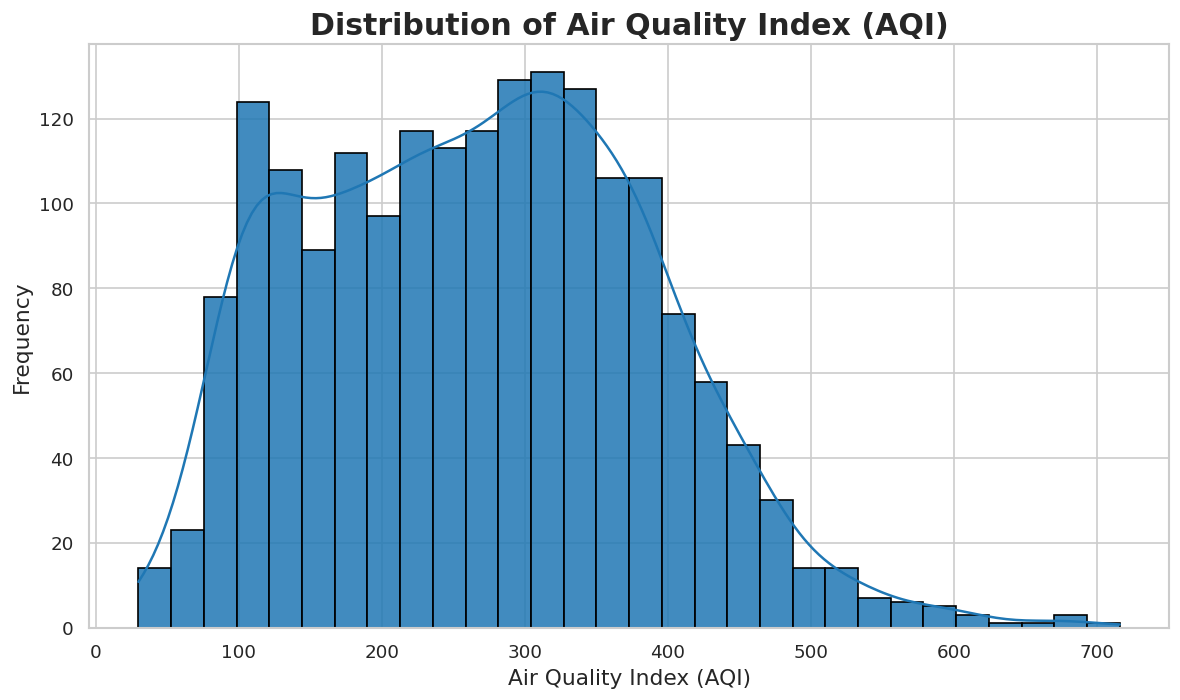

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=master_df,
    x="AQI",
    bins=30,
    kde=True,
    color=COLOR_PALETTE["AQI"],
    edgecolor="black",
    alpha=0.85
)

plt.title("Distribution of Air Quality Index (AQI)")
plt.xlabel("Air Quality Index (AQI)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2.2 Distribution of AQI Categories

The AQI categories are examined to understand the frequency of different pollution levels experienced during the study period. This analysis provides an overview of how often Delhi experienced good, moderate, poor, and severe air quality conditions according to the AQI classification.

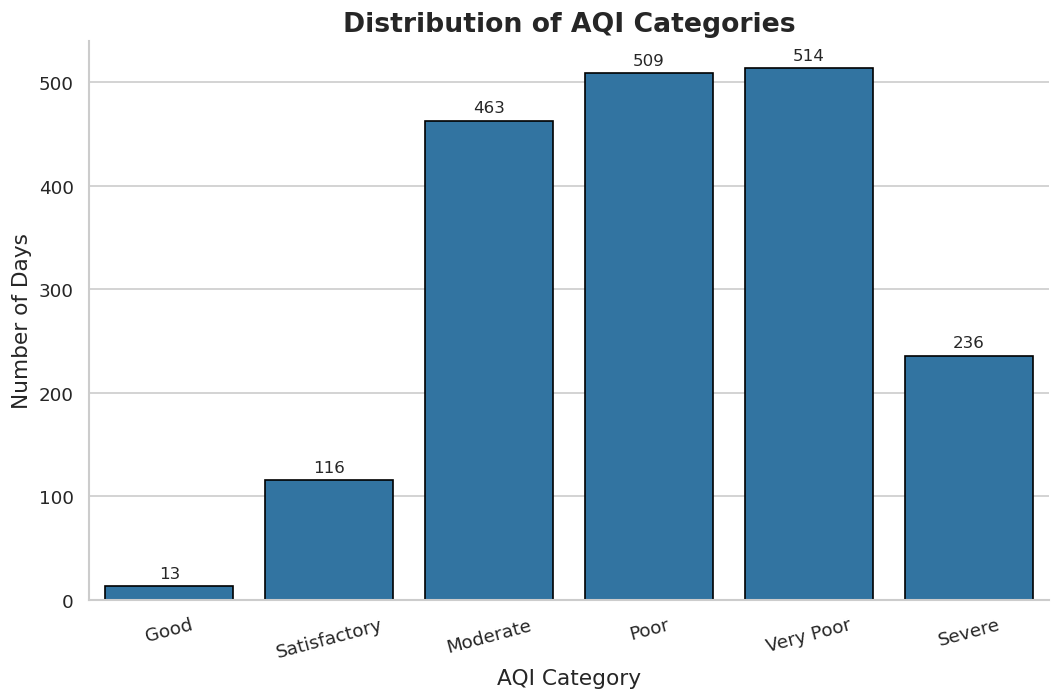

In [12]:
plt.figure(figsize=(9, 6))

order = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor",
    "Severe"
]

ax = sns.countplot(
    data=master_df,
    x="AQI_Bucket",
    order=order,
    color=COLOR_PALETTE["AQI"],
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10
    )

plt.title("Distribution of AQI Categories", fontsize=16, weight="bold")
plt.xlabel("AQI Category")
plt.ylabel("Number of Days")
plt.xticks(rotation=15)

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The AQI category distribution indicates that Delhi experienced **predominantly Poor, Very Poor, and Moderate** air quality during the study period. Days classified as **Good** or **Satisfactory** were relatively infrequent, whereas **Poor** and **Very Poor** categories accounted for the largest proportion of observations.

The presence of a considerable number of **Severe** air quality days further highlights the occurrence of extreme pollution episodes, emphasizing the need to investigate the contribution of external fire activity and meteorological conditions to deteriorating air quality.

## 2.3 Distribution of PM2.5

PM2.5 is one of the most harmful air pollutants due to its ability to penetrate deep into the respiratory system. Examining its distribution provides insights into the concentration levels observed during the study period and complements the AQI analysis.

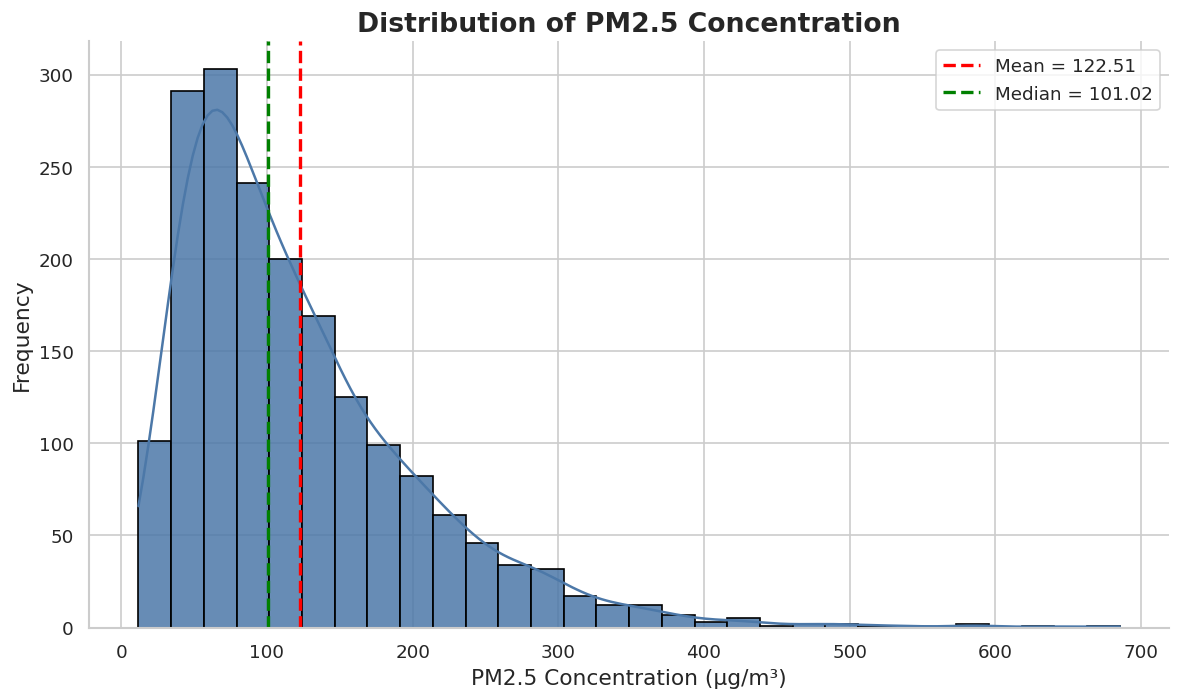

In [13]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="PM2.5",
    bins=30,
    kde=True,
    color=COLOR_PALETTE["PM2.5"],
    edgecolor="black",
    alpha=0.85
)

mean_pm = master_df["PM2.5"].mean()
median_pm = master_df["PM2.5"].median()

plt.axvline(
    mean_pm,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_pm:.2f}"
)

plt.axvline(
    median_pm,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_pm:.2f}"
)

plt.title("Distribution of PM2.5 Concentration", fontsize=16, weight="bold")
plt.xlabel("PM2.5 Concentration (µg/m³)")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The PM2.5 concentration exhibits a **positively skewed distribution**, with most observations occurring at relatively lower concentration levels and a long right tail representing high pollution episodes.

The mean PM2.5 concentration (**122.51 µg/m³**) is greater than the median (**101.02 µg/m³**), confirming the presence of right-skewness caused by occasional extreme pollution events. The wide spread of PM2.5 concentrations indicates substantial variability in particulate matter levels throughout the study period.

### Section Summary

The air quality analysis indicates that Delhi experienced predominantly **moderate to severe** air pollution during the study period. The AQI distribution shows frequent high pollution levels with occasional extreme pollution episodes, while the AQI category distribution reveals that **Poor** and **Very Poor** air quality conditions occurred most frequently. Similarly, the PM2.5 distribution demonstrates considerable variability and a positively skewed pattern, reflecting intermittent periods of exceptionally high particulate matter concentrations. These observations establish the baseline characteristics of Delhi's air quality and motivate further investigation into the influence of external fire activity and meteorological conditions.

# 3. Fire Activity Analysis

Fire activity is one of the primary explanatory variables considered in this study. This section examines the characteristics of external fire activity using the daily fire count and Fire Radiative Power (FRP) variables. Understanding the frequency and intensity of fire events provides the foundation for investigating their potential influence on Delhi's air quality.

## 3.1 Distribution of Daily Fire Count

The daily fire count represents the number of satellite-detected fire events within the selected study region for each day. Analyzing its distribution helps identify the frequency of fire occurrences and determine whether fire activity is concentrated around specific intensity levels or dominated by extreme events.

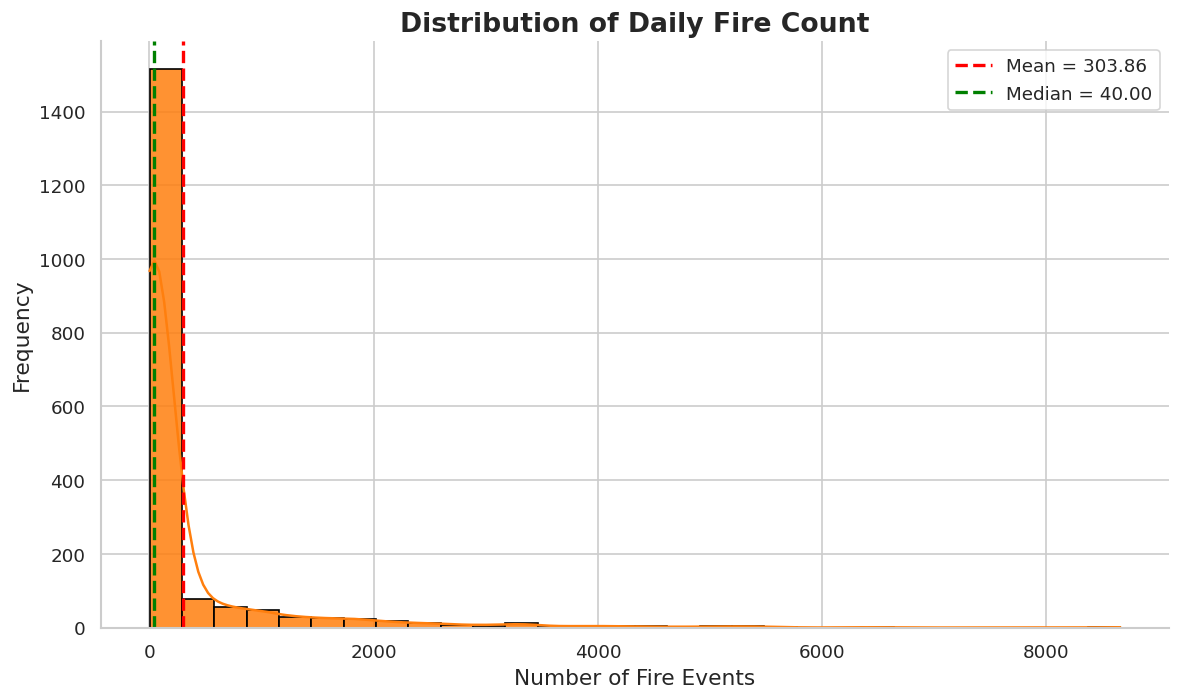

In [14]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="Fire_Count",
    bins=30,
    kde=True,
    color=COLOR_PALETTE["Fire"],
    edgecolor="black",
    alpha=0.85
)

mean_fire = master_df["Fire_Count"].mean()
median_fire = master_df["Fire_Count"].median()

plt.axvline(
    mean_fire,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_fire:.2f}"
)

plt.axvline(
    median_fire,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_fire:.2f}"
)

plt.title("Distribution of Daily Fire Count", fontsize=16, weight="bold")
plt.xlabel("Number of Fire Events")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The daily fire count exhibits a **highly positively skewed distribution**, with most days recording relatively few fire events and a small number of days experiencing exceptionally high fire activity.

The substantial difference between the **mean (303.86)** and the **median (40.00)** indicates that the distribution is strongly influenced by extreme fire events. These occasional spikes suggest the presence of seasonal fire episodes, which may have a significant impact on regional air quality and warrant further investigation in the subsequent temporal and relationship analyses.

## 3.2 Distribution of Total Fire Radiative Power (Total_FRP)

Total Fire Radiative Power (FRP) represents the cumulative intensity of all detected fire events on a given day. Analyzing its distribution provides insights into the daily magnitude of fire activity and helps determine whether fire intensity is dominated by frequent low-intensity events or occasional extreme fire episodes.

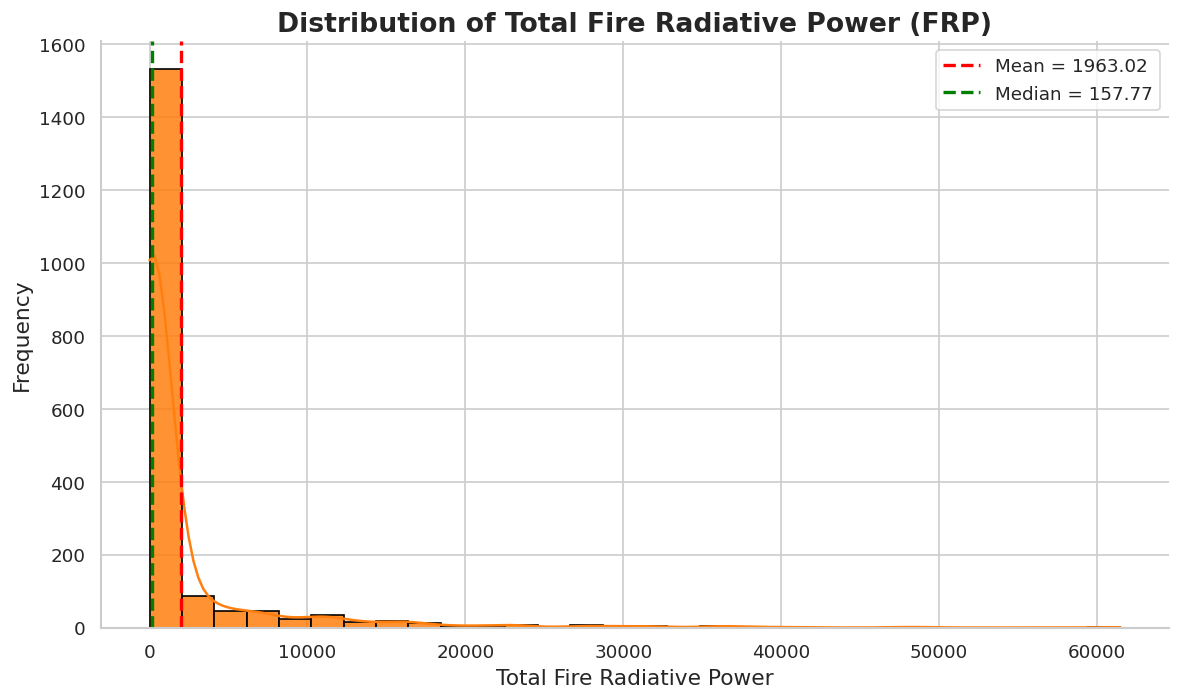

In [15]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="Total_FRP",
    bins=30,
    kde=True,
    color=COLOR_PALETTE["Fire"],
    edgecolor="black",
    alpha=0.85
)

mean_frp = master_df["Total_FRP"].mean()
median_frp = master_df["Total_FRP"].median()

plt.axvline(
    mean_frp,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_frp:.2f}"
)

plt.axvline(
    median_frp,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_frp:.2f}"
)

plt.title("Distribution of Total Fire Radiative Power (FRP)", fontsize=16, weight="bold")
plt.xlabel("Total Fire Radiative Power")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The distribution of **Total Fire Radiative Power (Total_FRP)** is highly positively skewed, with most days exhibiting relatively low cumulative fire intensity and a small number of days experiencing exceptionally high fire activity.

The large difference between the **mean (1963.02)** and the **median (157.77)** indicates that the distribution is dominated by a limited number of extreme fire events. These high-intensity fire episodes are likely associated with seasonal biomass burning and may contribute disproportionately to regional air pollution.

### Section Summary

The fire activity analysis indicates that both the daily fire count and total fire radiative power exhibit highly positively skewed distributions. Most days experienced relatively low to moderate fire activity, while a small number of days were characterized by exceptionally large fire events and high cumulative fire intensity.

The substantial differences between the mean and median values of both variables suggest that seasonal biomass burning events dominate the upper range of the distributions. These extreme fire episodes provide a strong basis for investigating whether periods of intensified fire activity are associated with deteriorating air quality in Delhi.

# 4. Meteorological Analysis

Meteorological conditions play a crucial role in the dispersion, accumulation, and transport of air pollutants. This section examines the distributions of key weather variables, including wind speed, temperature, and relative humidity, to understand the prevailing atmospheric conditions during the study period.

## 4.1 Distribution of Mean Wind Speed

Wind speed influences the transport and dispersion of airborne pollutants. Analyzing its distribution provides insight into the prevailing atmospheric conditions that may facilitate or inhibit the movement of smoke and particulate matter towards Delhi.

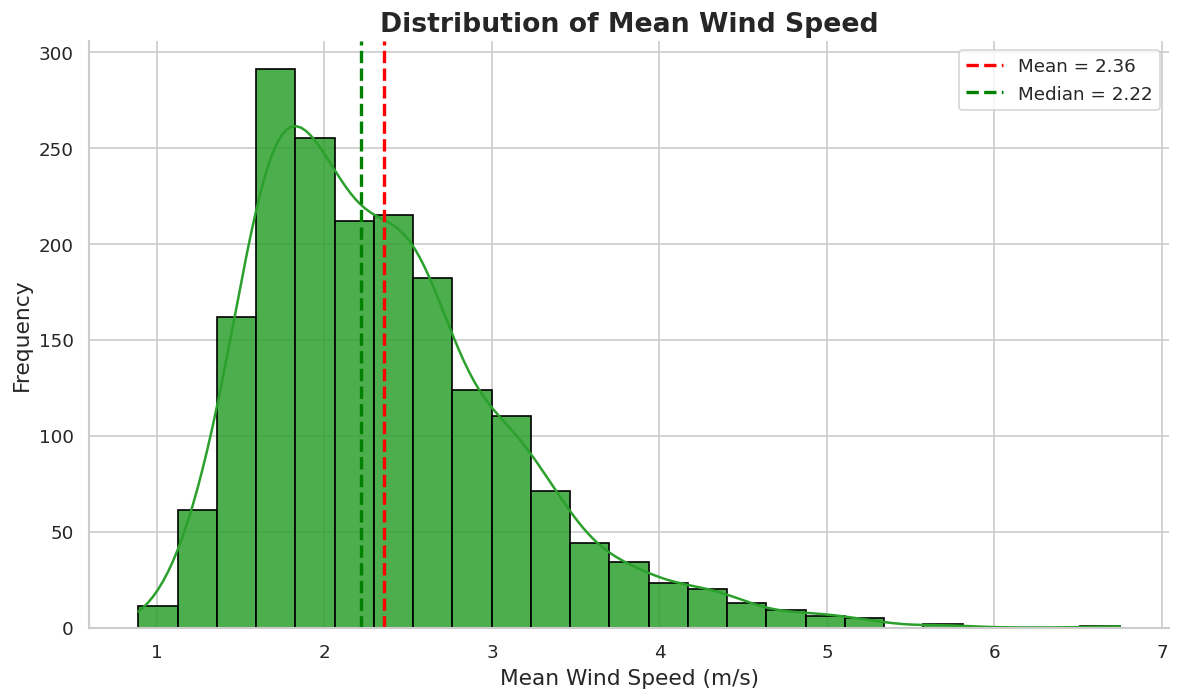

In [16]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="Mean_Wind_Speed",
    bins=25,
    kde=True,
    color=COLOR_PALETTE["Wind"],
    edgecolor="black",
    alpha=0.85
)

mean_ws = master_df["Mean_Wind_Speed"].mean()
median_ws = master_df["Mean_Wind_Speed"].median()

plt.axvline(
    mean_ws,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_ws:.2f}"
)

plt.axvline(
    median_ws,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_ws:.2f}"
)

plt.title("Distribution of Mean Wind Speed", fontsize=16, weight="bold")
plt.xlabel("Mean Wind Speed (m/s)")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The distribution of mean wind speed is **slightly positively skewed**, with most observations concentrated between **1.5 m/s and 3.0 m/s**. This indicates that moderate wind conditions were the most common during the study period.

The close proximity of the **mean (2.36 m/s)** and **median (2.22 m/s)** suggests that the distribution is relatively stable with only a few high wind speed events. Such wind conditions may influence the transport and dispersion of pollutants and will be further examined in the relationship analysis.

## 4.2 Distribution of Average Temperature

Temperature influences atmospheric stability and the chemical processes involved in pollutant formation. Examining its distribution provides an overview of the thermal conditions observed throughout the study period.

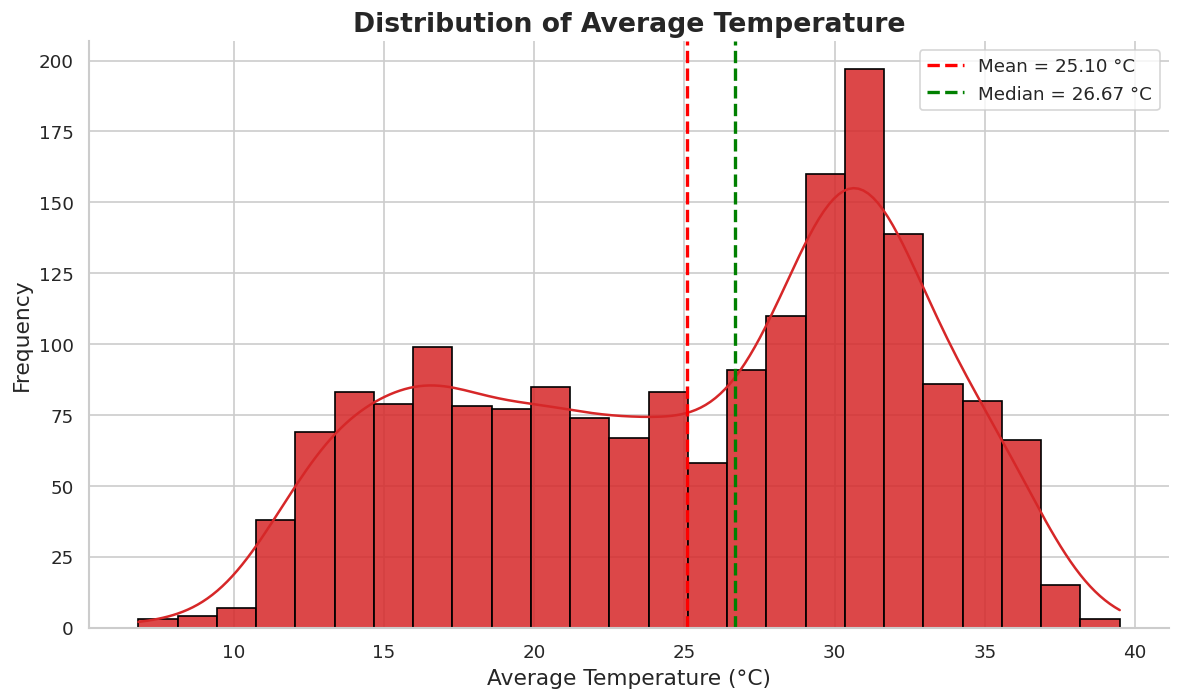

In [17]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="Avg_Temperature_C",
    bins=25,
    kde=True,
    color=COLOR_PALETTE["Temperature"],
    edgecolor="black",
    alpha=0.85
)

mean_temp = master_df["Avg_Temperature_C"].mean()
median_temp = master_df["Avg_Temperature_C"].median()

plt.axvline(
    mean_temp,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_temp:.2f} °C"
)

plt.axvline(
    median_temp,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_temp:.2f} °C"
)

plt.title("Distribution of Average Temperature", fontsize=16, weight="bold")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The distribution of average temperature exhibits a **bimodal pattern**, with one concentration of observations occurring at lower temperatures and another at higher temperatures. This reflects the seasonal climatic variation experienced in Delhi over the study period.

The **mean (25.10°C)** is slightly lower than the **median (26.67°C)**, indicating a mild negative skewness influenced by lower winter temperatures. The broad range of observed temperatures highlights substantial seasonal variability, which may affect atmospheric conditions and pollutant dispersion.

## 4.3 Distribution of Relative Humidity

Relative humidity influences atmospheric moisture content and can affect the formation, accumulation, and removal of air pollutants. Examining its distribution provides an understanding of the prevailing moisture conditions during the study period.

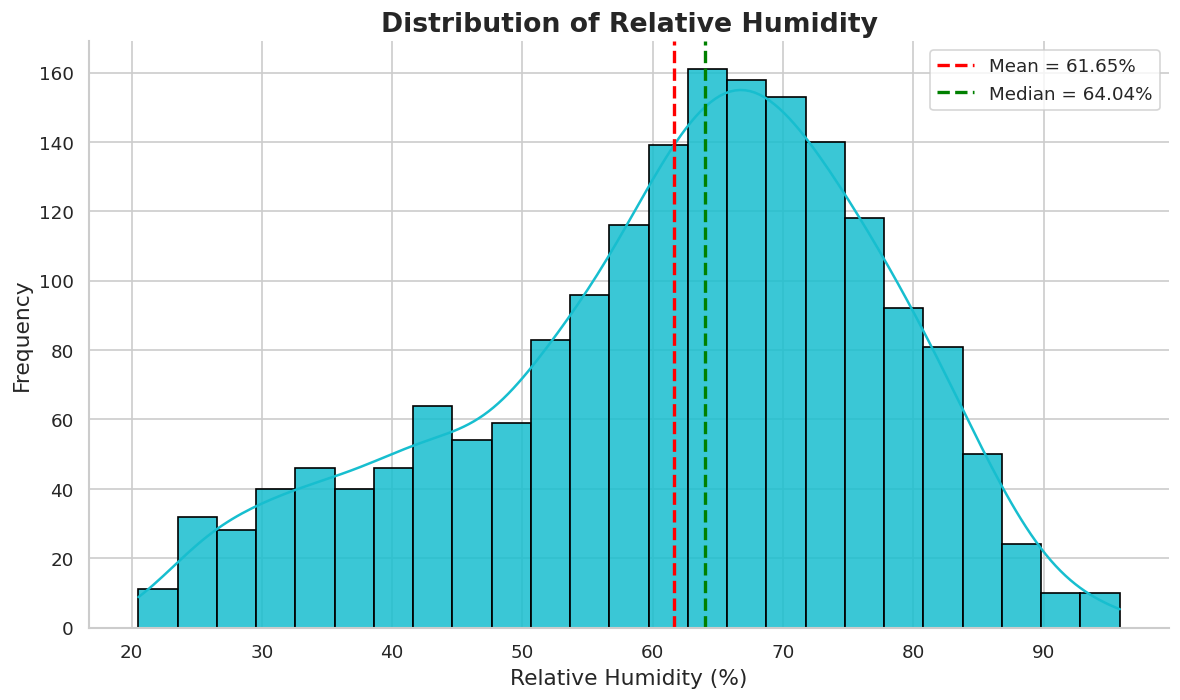

In [18]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="Relative_Humidity",
    bins=25,
    kde=True,
    color=COLOR_PALETTE["Humidity"],
    edgecolor="black",
    alpha=0.85
)

mean_rh = master_df["Relative_Humidity"].mean()
median_rh = master_df["Relative_Humidity"].median()

plt.axvline(
    mean_rh,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_rh:.2f}%"
)

plt.axvline(
    median_rh,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_rh:.2f}%"
)

plt.title("Distribution of Relative Humidity", fontsize=16, weight="bold")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The distribution of relative humidity is **slightly negatively skewed**, with most observations concentrated between **55% and 80%**. This indicates that moderate to high humidity conditions were common throughout the study period.

The **mean (61.65%)** is slightly lower than the **median (64.04%)**, suggesting that occasional low-humidity periods shifted the distribution towards lower values. Since atmospheric moisture influences pollutant dispersion and secondary aerosol formation, relative humidity will be further investigated in relation to AQI in the subsequent analyses.

### Section Summary

The meteorological analysis indicates that the study period was characterized by predominantly **moderate wind speeds**, **distinct seasonal temperature variations**, and **moderate to high relative humidity**. Wind speed exhibited relatively low variability compared to the fire variables, whereas temperature reflected Delhi's seasonal climate through a bimodal distribution. Relative humidity remained generally high throughout the study period, suggesting that meteorological conditions may have influenced the transport, dispersion, and accumulation of atmospheric pollutants. These weather variables will be further examined alongside fire activity during the temporal and relationship analyses.

# 5. Temporal Analysis

Temporal analysis examines how air quality, fire activity, and meteorological conditions change over time. Understanding these temporal patterns helps identify seasonal behaviour, long-term trends, and periods of unusually high pollution or fire activity. These observations provide the foundation for investigating whether changes in fire activity and weather conditions coincide with variations in Delhi's air quality.

## 5.1 Air Quality Index (AQI) Trend Over Time

The AQI time series is analysed to examine the variation in air quality throughout the study period. Visualising AQI over time helps identify pollution episodes, recurring seasonal patterns, and long-term changes in air quality.

In [19]:
fig = px.line(
    master_df,
    x="Date",
    y="AQI",
    color_discrete_sequence=[COLOR_PALETTE["AQI"]]
)

fig.update_layout(
    title={
        "text": "Daily Air Quality Index (AQI) Over Time",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Year",
    yaxis_title="Air Quality Index (AQI)",
    hovermode="x unified"
)

fig.show()

### Findings

The AQI time series exhibits substantial temporal variability throughout the study period, with recurring periods of elevated pollution levels observed across multiple years. Several extreme pollution episodes exceed **600 AQI**, indicating the occurrence of severe air quality events.

A clear seasonal pattern is also evident, with AQI increasing during certain periods of the year and decreasing during others. This recurring behaviour suggests that seasonal factors, including meteorological conditions and external fire activity, may influence Delhi's air quality and warrant further investigation.

## 5.2 Monthly Analysis

Monthly aggregation helps identify recurring seasonal patterns that may not be apparent in daily observations. By comparing monthly averages of air quality, fire activity, and meteorological variables, this analysis investigates whether periods of increased fire activity coincide with deteriorating air quality in Delhi.

In [20]:
monthly_df = (
    master_df
    .groupby(master_df["Date"].dt.month_name())
    .agg({
        "AQI": "mean",
        "Fire_Count": "mean",
        "Total_FRP": "mean",
        "Mean_Wind_Speed": "mean",
        "Avg_Temperature_C": "mean",
        "Relative_Humidity": "mean"
    })
    .reindex([
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ])
    .reset_index()
)

# Rename the first column
monthly_df.rename(columns={"Date": "Month"}, inplace=True)

display(monthly_df)

,Month,AQI,Fire_Count,Total_FRP,Mean_Wind_Speed,Avg_Temperature_C,Relative_Humidity
0,January,363.966292,37.556180,146.395112,2.236033,13.787291,75.015899
1,February,298.148810,42.696429,175.313810,2.416279,17.841088,67.249107
2,March,223.560440,26.939560,105.884670,2.394696,22.919325,59.171703
3,April,248.681564,97.625698,683.029050,2.601522,29.919600,41.861564
4,May,258.693548,727.069892,4791.637473,2.640166,33.231073,40.308656
5,June,200.447059,46.629412,222.822765,2.673666,33.697868,53.794765
6,July,138.210000,6.740000,23.143500,2.574803,31.274391,73.469400
7,August,130.956044,2.714286,6.504945,2.250865,30.434657,77.846484
8,September,160.496454,18.886525,80.923475,2.231995,29.592343,73.101135
9,October,312.329032,964.503226,6169.946774,1.871028,26.378476,63.459935


### 5.2.1 Monthly Average AQI

This analysis examines the average AQI for each month to identify recurring seasonal pollution patterns. Understanding these monthly variations provides a foundation for comparing AQI with fire activity and meteorological conditions.

In [21]:
fig = px.bar(
    monthly_df,
    x="Month",
    y="AQI",
    color="AQI",
    color_continuous_scale="Blues",
    text_auto=".1f"
)

fig.update_layout(
    title={
        "text": "Monthly Average AQI",
        "x": 0.5
    },
    xaxis_title="Month",
    yaxis_title="Average AQI",
    coloraxis_showscale=False
)

fig.show()

### Findings

The monthly analysis reveals a pronounced seasonal pattern in Delhi's air quality, fire activity, and meteorological conditions. Air quality is poorest during the winter months, with the highest average AQI recorded in **November (401.95)**, followed by **December (372.05)** and **January (363.97)**. In contrast, the cleanest air is observed during the monsoon season, particularly in **July (138.21)** and **August (130.96)**.

Fire activity follows a similar seasonal trend. Both **Fire Count** and **Total Fire Radiative Power (FRP)** increase dramatically during **October** and **November**, reaching their annual maxima in November with an average Fire Count of **1466.33** and Total FRP of **9991.75**. This temporal coincidence between peak fire activity and the highest AQI suggests a strong association between regional biomass burning and deteriorating air quality in Delhi.

Meteorological conditions also exhibit clear seasonal variations. Average temperatures rise steadily from winter to summer, peaking during **May (33.23°C)** and **June (33.70°C)**, before declining towards winter. However, despite these high summer temperatures, AQI remains relatively low compared to winter, indicating that temperature alone does not explain the seasonal pollution pattern.

Relative humidity is highest during the monsoon months, particularly in **July (73.47%)** and **August (77.85%)**, when AQI reaches its lowest levels. Increased humidity, together with seasonal rainfall, likely enhances the removal of airborne particulate matter through wet deposition, contributing to improved air quality. Conversely, humidity decreases during the pre-monsoon months before increasing again in winter.

Wind speed remains comparatively stable throughout the year, ranging between **1.87 m/s** and **2.67 m/s**, with only modest monthly variation. This suggests that wind speed alone is unlikely to be the primary driver of seasonal AQI fluctuations, although it may still influence pollutant transport and dispersion when considered alongside other atmospheric factors.

Overall, the monthly analysis provides preliminary evidence that the severe deterioration in Delhi's air quality during **October and November** coincides with periods of exceptionally high fire activity. While meteorological conditions contribute to pollutant dispersion and accumulation, the close temporal alignment between peak fire activity and elevated AQI supports the hypothesis that external biomass burning is an important contributor to seasonal air pollution in Delhi. These observations will be further examined through relationship analysis, correlation analysis, and statistical hypothesis testing.

### 5.2.2 Monthly Average Fire Count

To investigate whether periods of increased fire activity coincide with deteriorating air quality, the monthly average fire count is analysed. Comparing the seasonal variation in fire activity with the monthly AQI pattern provides preliminary evidence regarding the potential influence of external biomass burning on Delhi's air quality.

In [22]:
fig = px.bar(
    monthly_df,
    x="Month",
    y="Fire_Count",
    color="Fire_Count",
    color_continuous_scale="Oranges",
    text_auto=".1f"
)

fig.update_layout(
    title={
        "text": "Monthly Average Fire Count",
        "x": 0.5
    },
    xaxis_title="Month",
    yaxis_title="Average Fire Count",
    coloraxis_showscale=False,
    template="plotly_white"
)

fig.show()

### Findings

The monthly distribution of fire activity reveals a strong seasonal pattern, with fire occurrences concentrated in a few specific months. Fire activity remains relatively low from **January to April**, decreases further during the **monsoon months (July–September)**, and then increases sharply during **October** and **November**.

The highest average fire count is observed in **November (1466.33)**, followed by **October (964.50)**, indicating that these months experience the most intense biomass burning activity. A secondary peak is also evident in **May (727.07)**, suggesting the occurrence of another seasonal fire period, although its magnitude is substantially lower than the post-monsoon peak.

Comparing these observations with the monthly AQI analysis reveals that the months with the highest fire activity also correspond to the months with the poorest air quality. This temporal alignment provides preliminary evidence that increased regional fire activity may contribute to elevated pollution levels in Delhi. However, further analyses, including correlation analysis and hypothesis testing, are required to quantify the strength and significance of this relationship.

### 5.2.3 Monthly Average Total Fire Radiative Power (FRP)

While fire count represents the frequency of fire events, Total Fire Radiative Power (FRP) measures the cumulative intensity of those events. Examining the monthly variation in Total FRP provides additional insight into whether periods of intense fire activity coincide with deteriorating air quality.

In [23]:
fig = px.bar(
    monthly_df,
    x="Month",
    y="Total_FRP",
    color="Total_FRP",
    color_continuous_scale="Oranges",
    text_auto=".1f"
)

fig.update_layout(
    title={
        "text": "Monthly Average Total Fire Radiative Power (FRP)",
        "x": 0.5
    },
    xaxis_title="Month",
    yaxis_title="Average Total FRP",
    coloraxis_showscale=False,
    template="plotly_white"
)

fig.show()

### Findings

The monthly distribution of **Total Fire Radiative Power (FRP)** demonstrates a pronounced seasonal variation in fire intensity throughout the study period. Similar to the monthly fire count, Total FRP remains relatively low for most months but increases sharply during **October** and **November**, reaching its highest value in **November (9991.75)**.

A secondary increase in Total FRP is also observed during **May (4791.64)**, indicating another period of elevated fire intensity. However, both the frequency and cumulative intensity of fires during May remain considerably lower than those observed during the post-monsoon period.

The close agreement between the monthly patterns of **Fire Count** and **Total FRP** suggests that the months with the greatest number of fire events also experience the highest cumulative fire intensity. Furthermore, these months coincide with the highest average AQI levels observed in Delhi, providing additional evidence that periods of intense regional biomass burning are associated with severe air pollution episodes. These observations support the need for further statistical analyses to quantify the relationship between fire intensity and air quality.

### Monthly Analysis Summary

The monthly analysis reveals a clear seasonal pattern across air quality, fire activity, and meteorological conditions. Delhi experiences its poorest air quality during **October, November, December, and January**, with the highest average AQI occurring in **November**. In contrast, the lowest AQI levels are observed during the **monsoon months (July and August)**.

Fire activity exhibits an even stronger seasonal pattern. Both the **average fire count** and **Total Fire Radiative Power (FRP)** increase dramatically during **October and November**, indicating that these months experience both the highest frequency and the greatest intensity of regional fire events. A smaller secondary fire season is also evident during **May**, although its impact is considerably less pronounced.

Meteorological conditions display expected seasonal variability. Temperature peaks during the summer months, while relative humidity is highest during the monsoon season when AQI reaches its annual minimum. Wind speed varies only modestly throughout the year, suggesting that although atmospheric conditions influence pollutant dispersion, they alone do not explain the observed seasonal pollution pattern.

The close temporal alignment between the peaks in fire activity and the highest AQI levels provides preliminary evidence supporting the research hypothesis that external biomass burning contributes to the seasonal deterioration of Delhi's air quality. While these observations indicate a strong temporal association, subsequent relationship analysis, correlation analysis, and hypothesis testing are required to quantify and validate these relationships.

## 5.3 Seasonal Analysis

Seasonal aggregation provides a broader perspective on the variation in air quality, fire activity, and meteorological conditions throughout the year. Grouping observations into climatic seasons helps identify recurring environmental patterns and enables a clearer comparison of pollution levels, biomass burning activity, and weather conditions across different periods of the year.

In [24]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5, 6]:
        return "Summer"
    elif month in [7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

master_df["Season"] = master_df["Date"].dt.month.apply(get_season)

In [25]:
seasonal_df = (
    master_df
    .groupby("Season")
    .agg({
        "AQI": "mean",
        "Fire_Count": "mean",
        "Total_FRP": "mean",
        "Mean_Wind_Speed": "mean",
        "Avg_Temperature_C": "mean",
        "Relative_Humidity": "mean"
    })
    .reindex([
        "Winter",
        "Summer",
        "Monsoon",
        "Post-Monsoon"
    ])
    .reset_index()
)

display(seasonal_df)

,Season,AQI,Fire_Count,Total_FRP,Mean_Wind_Speed,Avg_Temperature_C,Relative_Humidity
0,Winter,344.173038,48.018109,188.076016,2.265964,15.554923,70.777505
1,Summer,233.465830,230.878661,1493.246374,2.576152,29.897549,48.681994
2,Monsoon,145.686747,10.795181,43.122018,2.340423,30.329859,74.512741
3,Post-Monsoon,356.406557,1211.304918,8049.521508,2.010950,23.695817,63.271541


### 5.3.1 Seasonal Average Air Quality Index (AQI)

Seasonal aggregation of AQI provides a clearer understanding of how air quality varies throughout the year. Comparing the average AQI across seasons helps identify periods of persistent pollution and provides a basis for examining whether these periods coincide with seasonal fire activity and changing meteorological conditions.

In [26]:
fig = px.bar(
    seasonal_df,
    x="Season",
    y="AQI",
    color="AQI",
    color_continuous_scale="Blues",
    text_auto=".1f"
)

fig.update_layout(
    title={
        "text": "Seasonal Average Air Quality Index (AQI)",
        "x": 0.5
    },
    xaxis_title="Season",
    yaxis_title="Average AQI",
    coloraxis_showscale=False,
    template="plotly_white"
)

fig.show()

### Findings

Seasonal analysis reveals a pronounced variation in Delhi's air quality throughout the year. The **highest average AQI** is observed during the **Post-Monsoon season (356.41)**, followed closely by **Winter (344.17)**, indicating that these seasons experience the most severe pollution conditions.

In contrast, the **Monsoon season records the lowest average AQI (145.69)**, representing the cleanest air quality of the year. Summer exhibits intermediate pollution levels with an average AQI of **233.47**.

These findings indicate that severe air pollution in Delhi is concentrated primarily during the **Post-Monsoon and Winter seasons**, suggesting that seasonal environmental factors play a significant role in determining air quality.

### 5.3.2 Seasonal Average Fire Count

Seasonal fire activity is analysed to determine whether biomass burning follows a recurring annual pattern. Comparing seasonal fire activity with seasonal AQI helps assess whether periods of elevated fire occurrence coincide with deteriorating air quality in Delhi.

In [27]:
fig = px.bar(
    seasonal_df,
    x="Season",
    y="Fire_Count",
    color="Fire_Count",
    color_continuous_scale="Oranges",
    text_auto=".1f"
)

fig.update_layout(
    title={
        "text": "Seasonal Average Fire Count",
        "x": 0.5
    },
    xaxis_title="Season",
    yaxis_title="Average Fire Count",
    coloraxis_showscale=False,
    template="plotly_white"
)

fig.show()

### Findings

Seasonal fire activity exhibits substantial variation throughout the year. The **Post-Monsoon season** records by far the **highest average fire count (1211.30)**, exceeding the values observed during all other seasons by a considerable margin. Summer records a moderate level of fire activity (**230.88**), while Winter (**48.02**) and Monsoon (**10.80**) experience comparatively few fire events.

The striking increase in fire activity during the **Post-Monsoon season** closely aligns with the season exhibiting the highest average AQI. This seasonal agreement provides strong observational evidence that periods of intensified biomass burning coincide with severe air pollution episodes in Delhi. Although this temporal relationship does not establish causation, it strongly supports further statistical investigation of the association between fire activity and air quality.

### 5.3.3 Seasonal Average Total Fire Radiative Power (FRP)

While the seasonal fire count represents the frequency of fire events, Total Fire Radiative Power (FRP) reflects their cumulative intensity. Analysing seasonal FRP helps determine whether periods of high fire intensity coincide with poor air quality, providing further evidence for the study's research objective.

In [28]:
fig = px.bar(
    seasonal_df,
    x="Season",
    y="Total_FRP",
    color="Total_FRP",
    color_continuous_scale="Oranges",
    text_auto=".1f"
)

fig.update_layout(
    title={
        "text": "Seasonal Average Total Fire Radiative Power (FRP)",
        "x": 0.5
    },
    xaxis_title="Season",
    yaxis_title="Average Total FRP",
    coloraxis_showscale=False,
    template="plotly_white"
)

fig.show()

### Findings

The seasonal distribution of **Total Fire Radiative Power (FRP)** highlights a substantial variation in fire intensity throughout the year. The **Post-Monsoon season** records the highest average Total FRP (**8049.52**), indicating that this period experiences the most intense and widespread biomass burning activity. Summer exhibits moderate fire intensity (**1493.25**), whereas Winter (**188.08**) and Monsoon (**43.12**) show comparatively low levels of fire activity.

The seasonal pattern of Total FRP closely mirrors that of both Fire Count and AQI. The simultaneous occurrence of maximum fire intensity and the highest average AQI during the **Post-Monsoon season** suggests a strong temporal association between regional biomass burning and deteriorating air quality. These observations provide additional support for investigating fire-related variables as potential predictors of Delhi's AQI in the subsequent modelling stage.

### Seasonal Analysis Summary

Seasonal analysis demonstrates clear and consistent variations in air quality, fire activity, and meteorological conditions across the study period. The **Post-Monsoon season** experiences both the **highest AQI** and the **greatest fire activity**, recording the largest average Fire Count and Total Fire Radiative Power (FRP). This close seasonal alignment provides strong observational evidence that periods of intensified biomass burning coincide with severe air pollution episodes in Delhi.

Conversely, the **Monsoon season** records the lowest AQI together with minimal fire activity. Higher relative humidity and seasonal rainfall during this period are likely to facilitate the removal of airborne pollutants, resulting in improved air quality. Although Summer experiences higher temperatures and moderate fire activity, pollution levels remain substantially lower than those observed during the Post-Monsoon and Winter seasons.

Overall, the seasonal analysis strengthens the evidence obtained from the monthly analysis by demonstrating that the most severe air pollution consistently occurs during periods characterised by intense biomass burning. While these findings indicate a strong temporal association, further relationship analysis, correlation analysis, and statistical hypothesis testing are required to quantify the influence of fire activity and meteorological conditions on Delhi's air quality.

# 6. Relationship Analysis

The previous analyses identified seasonal patterns in air quality, fire activity, and meteorological conditions. This section investigates the direct relationships between AQI and fire-related variables through scatter plots and regression analysis. These visualizations provide an initial assessment of the direction and nature of these associations before they are quantified using correlation analysis and further evaluated through predictive modelling.

## 6.1 Relationship Between AQI and Fire Count

Fire Count represents the daily number of satellite-detected fire events. Examining its relationship with AQI helps determine whether increased fire activity is associated with higher levels of air pollution in Delhi.

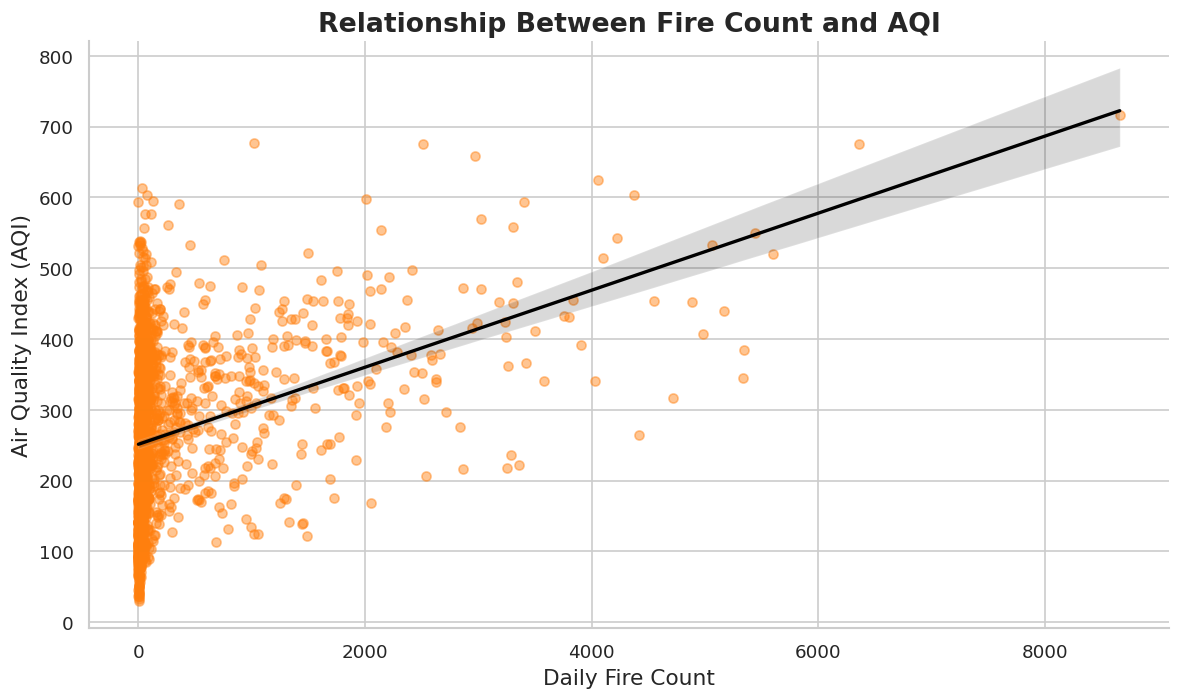

In [29]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=master_df,
    x="Fire_Count",
    y="AQI",
    scatter_kws={
        "alpha": 0.45,
        "color": COLOR_PALETTE["Fire"],
        "s": 30
    },
    line_kws={
        "color": "black",
        "linewidth": 2
    }
)

plt.title(
    "Relationship Between Fire Count and AQI",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Daily Fire Count")
plt.ylabel("Air Quality Index (AQI)")

sns.despine()

plt.tight_layout()

plt.show()

### Findings

The scatter plot indicates a moderate positive relationship between daily Fire Count and AQI. The upward slope of the fitted regression line suggests that, on average, AQI tends to increase as the number of fire events increases.

However, the relationship is not perfectly linear. A large proportion of observations are concentrated at relatively low fire counts, where AQI exhibits substantial variability. This indicates that although fire activity contributes to air pollution, it is not the sole factor influencing AQI. Meteorological conditions, local emission sources, and atmospheric dispersion also play important roles in determining daily air quality.

Several observations with exceptionally high fire counts are associated with elevated AQI values, reinforcing the seasonal patterns identified in the temporal analysis. These extreme fire events are likely linked to periods of intensive biomass burning, particularly during the Post-Monsoon season.

Overall, the positive trend observed in the regression line provides preliminary evidence supporting the research hypothesis that increased regional fire activity is associated with poorer air quality in Delhi. The strength of this relationship will be quantified in the subsequent correlation analysis.

## 6.2 Relationship Between AQI and Total Fire Radiative Power (FRP)

While Fire Count represents the number of detected fire events, Total Fire Radiative Power (FRP) measures the cumulative intensity of those fires. Analysing the relationship between Total FRP and AQI helps determine whether more intense biomass burning is associated with higher levels of air pollution.

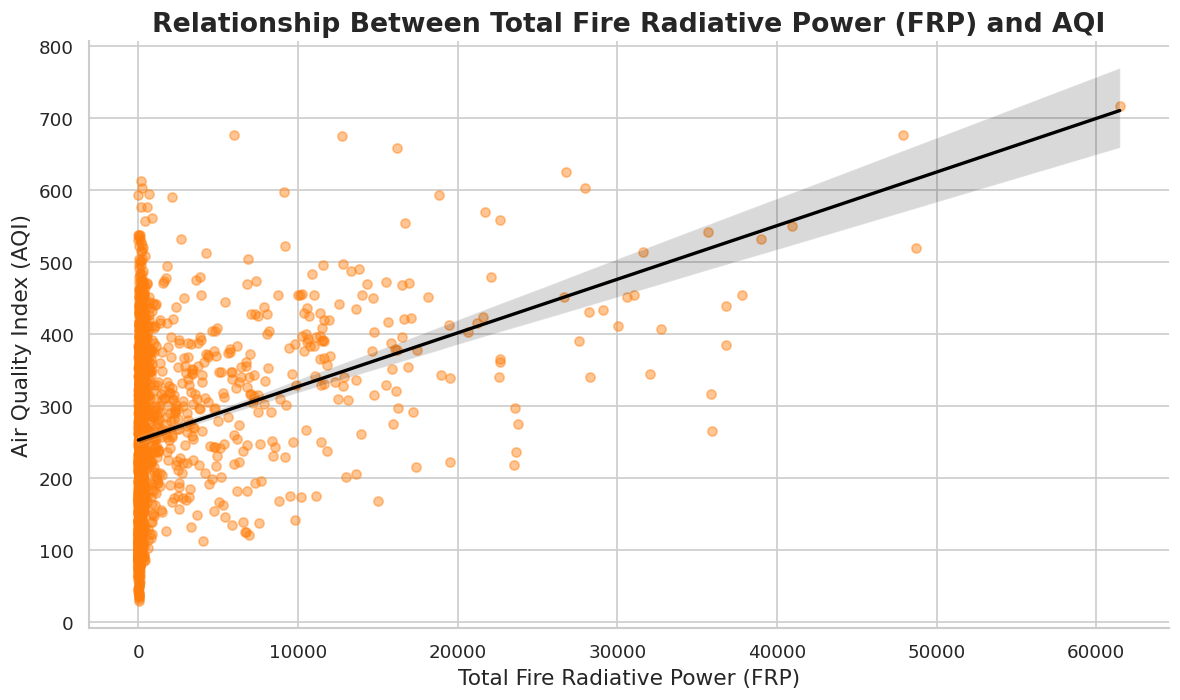

In [30]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=master_df,
    x="Total_FRP",
    y="AQI",
    scatter_kws={
        "alpha": 0.45,
        "color": COLOR_PALETTE["Fire"],
        "s": 30
    },
    line_kws={
        "color": "black",
        "linewidth": 2
    }
)

plt.title(
    "Relationship Between Total Fire Radiative Power (FRP) and AQI",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Total Fire Radiative Power (FRP)")
plt.ylabel("Air Quality Index (AQI)")

sns.despine()

plt.tight_layout()

plt.show()

### Findings

The relationship between Total Fire Radiative Power (FRP) and AQI exhibits a positive trend, indicating that days characterised by more intense biomass burning generally tend to experience higher AQI values. Compared with Fire Count, Total FRP reflects the cumulative intensity of biomass burning, thereby providing a complementary measure of regional fire activity.

Despite the positive association, noticeable variability remains across the observations, suggesting that fire intensity alone cannot fully explain daily AQI fluctuations. Meteorological conditions and other pollution sources continue to influence air quality alongside biomass burning.

The upward regression trend further supports the hypothesis that periods of intense regional biomass burning are associated with elevated pollution levels in Delhi. The strength of this relationship will be quantified in the subsequent correlation analysis.

### Relationship Analysis Summary

The relationship analysis provided an initial visual assessment of the association between regional biomass burning and Delhi's air quality. Two complementary indicators of fire activity were examined: **Fire Count**, representing the frequency of fire events, and **Total Fire Radiative Power (FRP)**, representing the cumulative intensity of biomass burning.

Both scatter plots demonstrated positive relationships with AQI, indicating that days characterised by increased fire activity or greater fire intensity generally tend to experience poorer air quality. However, considerable variability was observed in both relationships, suggesting that biomass burning alone does not fully explain daily AQI fluctuations. Meteorological conditions and other emission sources are also likely to influence pollution levels.

While the relationship analysis provides important visual evidence supporting the association between biomass burning and AQI, it primarily serves as an exploratory assessment of these relationships. The following correlation analysis quantifies the strength of the relationships among all numerical variables simultaneously and identifies potential redundancy between predictors, thereby providing a stronger statistical basis for subsequent feature engineering and predictive modelling.

# 7. Correlation Analysis

The previous analyses explored the distribution, temporal behaviour, and seasonal variation of air quality, fire activity, and meteorological variables. This section quantifies the linear relationships between these variables using Pearson's correlation coefficient. The analysis helps identify which factors exhibit the strongest associations with AQI and provides guidance for feature selection, feature engineering, and predictive modelling.

## 7.1 Pearson Correlation Matrix

Pearson's correlation coefficient is used to measure the strength and direction of the linear relationship between numerical variables. The coefficient ranges from **−1** to **+1**, where positive values indicate that two variables increase together, negative values indicate an inverse relationship, and values close to zero suggest little or no linear association.

In [31]:
corr_columns = [
    "AQI",
    "PM2.5",
    "Fire_Count",
    "Total_FRP",
    "Mean_FRP",
    "Max_FRP",
    "Mean_Wind_Speed",
    "Max_Wind_Speed",
    "Avg_Temperature_C",
    "Relative_Humidity"
]

correlation_matrix = master_df[corr_columns].corr(method="pearson")

display(correlation_matrix)

,AQI,PM2.5,Fire_Count,Total_FRP,Mean_FRP,Max_FRP,Mean_Wind_Speed,Max_Wind_Speed,Avg_Temperature_C,Relative_Humidity
AQI,1.000000,0.879679,0.350280,0.337261,0.262847,0.323591,-0.145237,-0.217191,-0.435119,-0.105148
PM2.5,0.879679,1.000000,0.379680,0.367252,0.190849,0.273685,-0.258963,-0.336414,-0.536970,0.078907
Fire_Count,0.350280,0.379680,1.000000,0.987615,0.390968,0.630777,-0.091690,-0.107196,0.036608,-0.164093
Total_FRP,0.337261,0.367252,0.987615,1.000000,0.414951,0.645061,-0.077771,-0.093403,0.039611,-0.167346
Mean_FRP,0.262847,0.190849,0.390968,0.414951,1.000000,0.719640,0.056447,0.073254,0.148513,-0.440616
Max_FRP,0.323591,0.273685,0.630777,0.645061,0.719640,1.000000,0.043321,0.035582,0.109058,-0.421338
Mean_Wind_Speed,-0.145237,-0.258963,-0.091690,-0.077771,0.056447,0.043321,1.000000,0.857164,0.172707,-0.270825
Max_Wind_Speed,-0.217191,-0.336414,-0.107196,-0.093403,0.073254,0.035582,0.857164,1.000000,0.336366,-0.330115
Avg_Temperature_C,-0.435119,-0.536970,0.036608,0.039611,0.148513,0.109058,0.172707,0.336366,1.000000,-0.500263
Relative_Humidity,-0.105148,0.078907,-0.164093,-0.167346,-0.440616,-0.421338,-0.270825,-0.330115,-0.500263,1.000000


## 7.2 Correlation Heatmap

The correlation heatmap provides a visual representation of the relationships among the study variables. Strong positive correlations are represented by darker warm colours, whereas strong negative correlations appear in cooler colours. This visualization helps identify variables that are most closely associated with AQI and highlights potential multicollinearity among predictor variables.

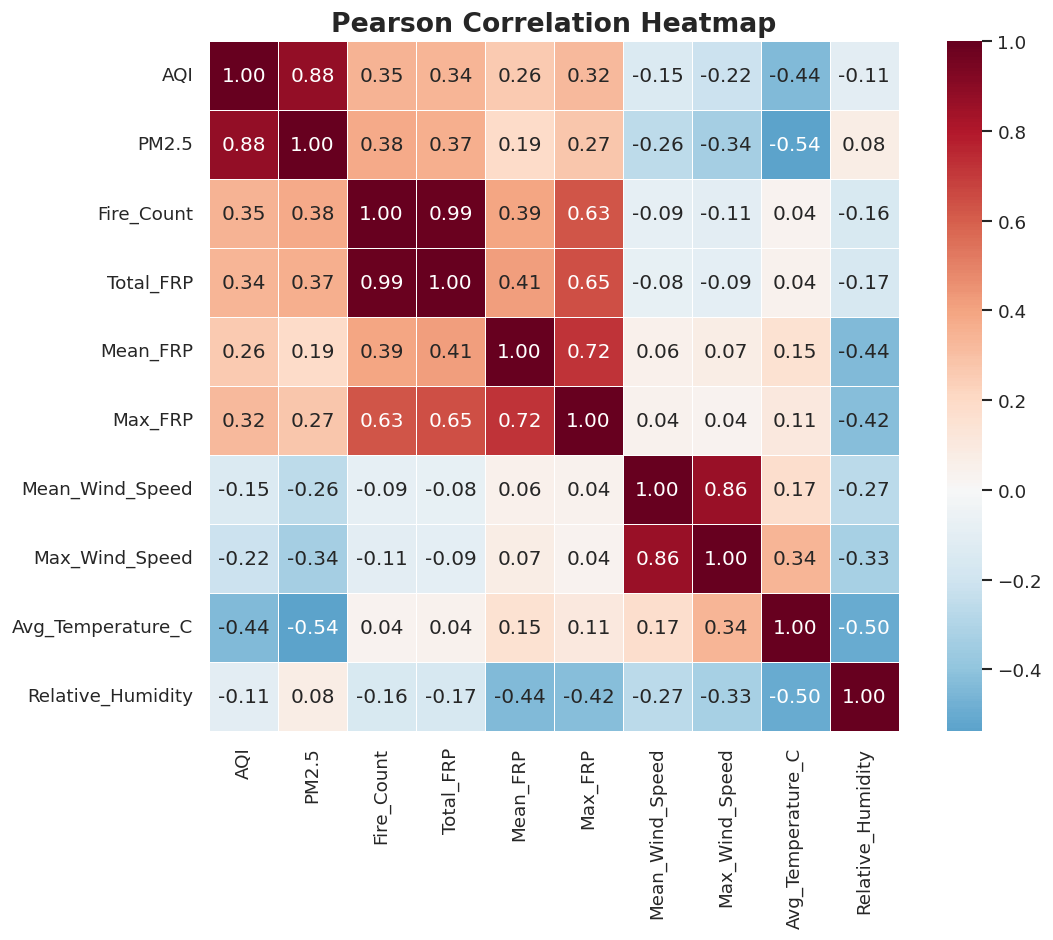

In [32]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Pearson Correlation Heatmap",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.show()

### Findings

The Pearson correlation analysis provides quantitative evidence of the relationships between AQI, fire activity, and meteorological variables.

As expected, **PM2.5** exhibits the strongest positive correlation with AQI (**r = 0.88**), confirming that particulate matter is the primary pollutant influencing the Air Quality Index.

Among the fire-related variables, **Fire Count** shows a moderate positive correlation with AQI (**r = 0.35**), indicating that higher levels of fire activity are generally associated with poorer air quality. Similarly, **Total Fire Radiative Power (FRP)** also demonstrates a positive relationship with AQI, reinforcing the observation that both the frequency and intensity of biomass burning contribute to air pollution.

A notable finding is the near-perfect correlation between **Fire Count** and **Total FRP (r = 0.99)**. This indicates that periods with a larger number of fire events are also characterised by greater cumulative fire intensity. Consequently, both variables capture highly similar information regarding regional biomass burning, although they represent different physical characteristics of fire activity.

Among the meteorological variables, **Average Temperature** exhibits a moderate negative correlation with AQI (**r = -0.44**), reflecting the seasonal tendency for poorer air quality during cooler months. In contrast, **Mean Wind Speed**, **Maximum Wind Speed**, and **Relative Humidity** display relatively weak negative correlations with AQI, suggesting that these variables alone have limited linear relationships with daily air quality.

Overall, the correlation analysis indicates that regional biomass burning is positively associated with AQI but is not the sole determinant of air quality. The findings suggest that Delhi's air quality is governed by a combination of fire activity, seasonal meteorological conditions, and other pollution sources. These observations provide a strong foundation for the subsequent feature engineering stage, where fire-related and weather-related variables will be combined to better capture their collective influence on AQI prediction.

### Correlation Analysis Summary

The correlation analysis quantitatively confirmed several patterns identified during the exploratory analysis. Fire-related variables exhibited positive associations with AQI, while meteorological variables generally showed weaker linear relationships. The near-perfect correlation between Fire Count and Total Fire Radiative Power indicates that both variables describe similar aspects of biomass burning, although they represent different physical characteristics of fire activity.

The moderate correlation between fire activity and AQI suggests that regional biomass burning contributes to deteriorating air quality but is unlikely to be the sole driver of pollution levels. This reinforces the need to consider both fire-related and meteorological variables simultaneously during feature engineering and predictive modelling.

Overall, the correlation analysis provides a quantitative foundation for the next stage of the study, where engineered features will be developed to better capture the combined influence of biomass burning and weather conditions on AQI prediction.

# 8. Outlier Analysis

Environmental datasets frequently contain extreme observations resulting from severe pollution episodes, large-scale biomass burning, or unusual meteorological conditions. Unlike many business datasets, these observations often represent genuine environmental events rather than data collection errors.

This section examines the presence of outliers in the key variables using boxplots. The objective is to identify extreme observations and evaluate whether they represent plausible environmental phenomena that should be retained for subsequent feature engineering and predictive modelling.

## 8.1 Outlier Analysis of Air Quality Index (AQI)

The distribution of AQI is examined using a boxplot to identify unusually high or low pollution levels. Extreme AQI observations may correspond to severe pollution episodes and therefore require careful assessment before deciding whether any preprocessing is necessary.

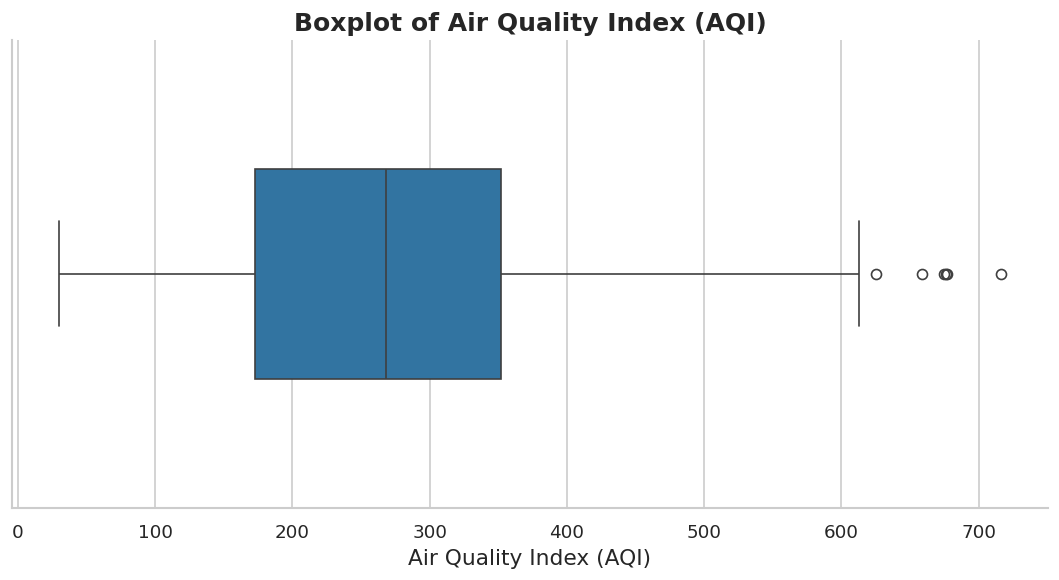

In [33]:
plt.figure(figsize=(9,5))

sns.boxplot(
    x=master_df["AQI"],
    color=COLOR_PALETTE["AQI"],
    width=0.45
)

plt.title(
    "Boxplot of Air Quality Index (AQI)",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Air Quality Index (AQI)")

sns.despine()

plt.tight_layout()

plt.show()

### Findings

The boxplot indicates the presence of a small number of observations beyond the upper whisker, representing days with exceptionally high AQI values. These extreme observations are relatively infrequent, suggesting that severe pollution episodes occur only during limited periods rather than throughout the entire study duration.

No significant lower-end outliers are observed, indicating that the lower range of AQI values remains comparatively stable.

When interpreted alongside the temporal and seasonal analyses, the upper outliers are consistent with the severe pollution episodes observed during the Post-Monsoon and Winter seasons. Therefore, these observations are considered plausible environmental events rather than obvious data quality issues. Since these extreme pollution events are directly relevant to the objectives of this study, they will be retained for subsequent feature engineering and predictive modelling.

## 8.2 Outlier Analysis of Fire Count

The boxplot of Fire Count is used to identify days with unusually high regional fire activity. These extreme observations may correspond to large-scale biomass burning events and therefore require further interpretation before any preprocessing decisions are made.

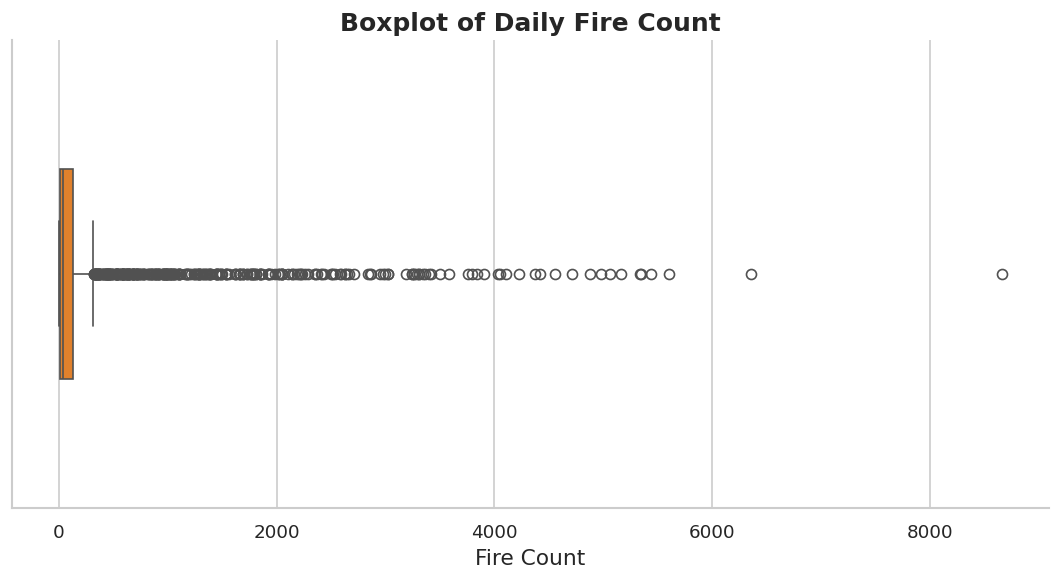

In [36]:
plt.figure(figsize=(9,5))

sns.boxplot(
    x=master_df["Fire_Count"],
    color=COLOR_PALETTE["Fire"],
    width=0.45
)

plt.title(
    "Boxplot of Daily Fire Count",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Fire Count")

sns.despine()

plt.tight_layout()

plt.show()

### Findings

The boxplot reveals a highly right-skewed distribution of Fire Count, with the majority of observations concentrated at relatively low fire counts and a long upper tail extending towards exceptionally large fire events.

A considerable number of observations are identified as upper-end outliers. However, these values form a continuous distribution rather than isolated anomalous points, indicating that they are consistent with periods of intensified biomass burning rather than obvious data quality issues.

These extreme fire events correspond closely with the seasonal peaks identified during the temporal analysis, particularly during the Post-Monsoon period. Since the objective of this study is to investigate the influence of regional biomass burning on Delhi's air quality, these observations represent meaningful environmental events and will therefore be retained for subsequent feature engineering and predictive modelling.

## 8.3 Outlier Analysis of Total Fire Radiative Power (FRP)

The distribution of Total Fire Radiative Power (FRP) is examined to identify exceptionally intense biomass burning events. Large FRP values may represent periods of severe fire intensity and therefore require careful evaluation before deciding whether they should be retained.

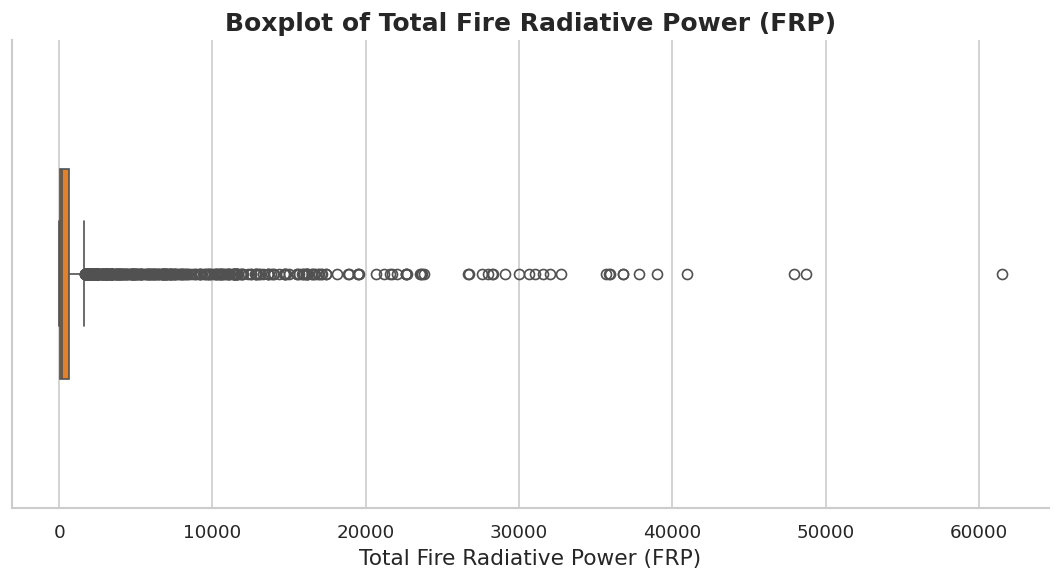

In [37]:
plt.figure(figsize=(9,5))

sns.boxplot(
    x=master_df["Total_FRP"],
    color=COLOR_PALETTE["Fire"],
    width=0.45
)

plt.title(
    "Boxplot of Total Fire Radiative Power (FRP)",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Total Fire Radiative Power (FRP)")

sns.despine()

plt.tight_layout()

plt.show()

### Findings

The distribution of Total Fire Radiative Power (FRP) is also highly right-skewed, with most observations representing relatively low fire intensity and a small proportion corresponding to exceptionally intense biomass burning events.

Numerous upper-end outliers are observed, forming a continuous upper tail rather than isolated extreme values. This pattern suggests that these observations represent genuine periods of severe biomass burning rather than measurement errors or anomalous records.

The similarity between the Fire Count and Total FRP distributions is consistent with the strong positive relationship identified during the correlation analysis, indicating that periods with more fire events are generally accompanied by greater cumulative fire intensity.

Accordingly, these extreme FRP observations are retained, as they represent important environmental events directly relevant to the objectives of this research.

### Outlier Analysis Summary

The outlier analysis confirms the presence of extreme observations in AQI, Fire Count, and Total Fire Radiative Power (FRP). These extreme values are concentrated primarily in the upper ranges of the distributions and are consistent with the severe pollution episodes and intensive biomass burning events identified throughout the temporal, seasonal, and relationship analyses.

Rather than representing measurement errors or data quality issues, these observations reflect genuine environmental phenomena that are central to the objectives of this study. Consequently, no outlier removal or transformation is performed, ensuring that the dataset preserves the full range of environmental conditions required for subsequent feature engineering and predictive modelling.

# 9. Exploratory Data Analysis Summary

The exploratory data analysis provided a comprehensive understanding of the characteristics, temporal behaviour, and relationships among air quality, fire activity, and meteorological variables. The findings establish a strong analytical foundation for the subsequent feature engineering and predictive modelling stages.

The distribution analysis revealed that Delhi experienced predominantly moderate to severe air pollution throughout the study period, with PM2.5 emerging as the dominant pollutant contributing to variations in the Air Quality Index (AQI). The presence of a right-skewed AQI distribution indicated that extreme pollution episodes occurred during specific periods rather than uniformly across the study duration.

Temporal and seasonal analyses demonstrated pronounced seasonal variations in both air quality and biomass burning. AQI levels reached their maximum during the Post-Monsoon and Winter seasons, while fire activity peaked during the Post-Monsoon period. Conversely, the Monsoon season exhibited the lowest AQI and fire activity, highlighting the strong influence of seasonal environmental conditions on air quality.

The relationship analysis showed that both Fire Count and Total Fire Radiative Power (FRP) exhibit positive associations with AQI. These findings suggest that increased biomass burning is generally accompanied by deteriorating air quality. However, the considerable variability observed within these relationships indicates that biomass burning alone cannot fully explain day-to-day changes in AQI.

Correlation analysis further quantified these relationships. PM2.5 exhibited the strongest positive correlation with AQI, while Fire Count demonstrated a moderate positive association, indicating that regional fire activity contributes to elevated pollution levels but is unlikely to be the sole determinant of AQI. Fire Count and Total FRP were found to be almost perfectly correlated, confirming that both variables describe closely related aspects of regional biomass burning. Among the meteorological variables, Average Temperature displayed the strongest inverse relationship with AQI, whereas wind speed and relative humidity exhibited comparatively weaker linear associations.

Finally, the outlier analysis confirmed that the extreme observations identified in AQI, Fire Count, and Total FRP correspond to genuine environmental events rather than obvious data quality issues. Consequently, these observations were retained to preserve important pollution episodes and biomass burning events within the dataset.

Overall, the exploratory analysis indicates that Delhi's air quality is governed by the combined influence of regional biomass burning and meteorological conditions rather than any single environmental factor. These findings justify the development of engineered features that integrate fire activity and weather information, providing the foundation for constructing robust machine learning models capable of predicting next-day AQI.

## Key Findings from Exploratory Data Analysis

- Delhi experienced predominantly moderate to severe air pollution during the study period, with PM2.5 identified as the primary contributor to AQI.
- Air quality exhibited strong seasonal variation, with the highest AQI levels observed during the Post-Monsoon and Winter seasons.
- Regional biomass burning also followed a pronounced seasonal pattern, reaching its peak during the Post-Monsoon season.
- Both Fire Count and Total Fire Radiative Power (FRP) demonstrated positive relationships with AQI, indicating that increased biomass burning is generally associated with poorer air quality.
- Pearson correlation analysis showed a moderate positive relationship between Fire Count and AQI, suggesting that biomass burning contributes to AQI variability but does not solely determine pollution levels.
- Fire Count and Total FRP exhibited a near-perfect positive correlation, indicating that the frequency and cumulative intensity of biomass burning capture closely related information.
- Meteorological variables influenced AQI to varying degrees, with Average Temperature exhibiting the strongest inverse relationship among the weather variables considered.
- Extreme observations in AQI and fire-related variables were identified as genuine environmental events and retained for subsequent feature engineering and predictive modelling.
- The combined findings support the hypothesis that both biomass burning and meteorological conditions influence Delhi's air quality, motivating the development of integrated predictive models using engineered fire and weather features.